In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

df=pd.read_csv('ab_test_data.csv')

In [ ]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     19998 non-null  object
 1   timestamp   19998 non-null  object
 2   test_group  19998 non-null  object
 3   conversion  19998 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 625.1+ KB


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
users = df.groupby('test_group')['user_id'].count()
users

,user_id
test_group,
a,10013
b,9985


In [ ]:
conversions = df.groupby('test_group')['conversion'].sum()
conversions

,conversion
test_group,
a,611
b,889


In [ ]:
cr = conversions/users
print(cr)

test_group
a    0.061021
b    0.089034
dtype: float64


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
start_date = df['timestamp'].min()
end_date = df['timestamp'].max()
duration = end_date-start_date
print(start_date)
print(end_date )
print(duration)

2023-07-03 01:42:34.033708
2023-07-25 01:41:19.152664
21 days 23:58:45.118956


In [ ]:
from scipy import stats
from scipy.stats import alpha
conv_A = conversions['a']
conv_B = conversions['b']
n_A = users['a']
n_B = users['b']
stat, p_value = proportions_ztest([conv_A, conv_B], [n_A, n_B])
print(f'z-statistic: (statistic:.4f)' )
print(p_value, alpha)
alpha = 0.05
if p_value < alpha:
  print(f'p_value equals{round(p_value,4)},Null hypothesis can be rejected')
else:
  print(f'p_value equals{round(p_value,4)},Null hypothesis cannot be rejected')



z-statistic: (statistic:.4f)
5.491217728445103e-14 <scipy.stats._continuous_distns.alpha_gen object at 0x7aa98fc66f30>
p_value equals0.0,Null hypothesis can be rejected


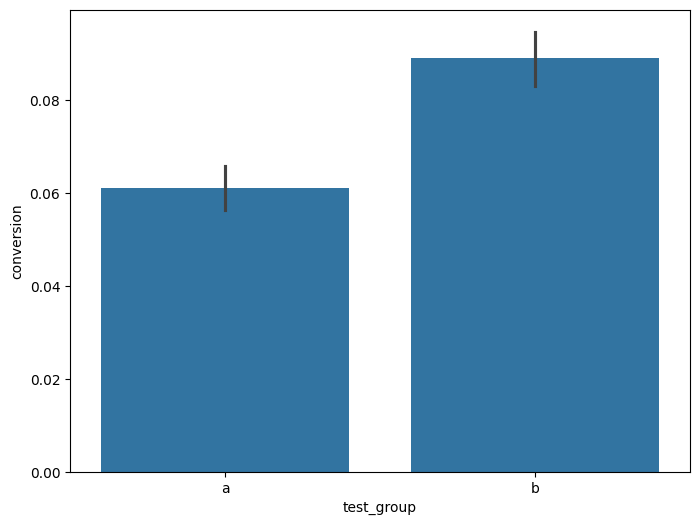

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
ci = 1 - alpha
ci_percent = ci*100
sns.barplot(
    data=df,
    x='test_group',
    y='conversion',
    errorbar=('ci',95)
)
plt.show()
plt.savefig('conversion_rate.png')
from google.colab import files
files.download('conversion_rate.png')


In [48]:
from google.colab import files
files.download('conversion_rate.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Висновки
Тест тривав майже 22 дні (з 3 по 25 липня 2023 року). В тесті взяли участь 10013 користувачів в контрольній групі (група А) та 9985 в тестовій(група В).
Конверсія : Група А (контроль) - 6,1%
Група В (тест) - 8,9%. Приріст становить 2,8% ,або майже 46% відносно бази.
Було застосовано двовибірковий Z-тест для пропорцій. Отримане значення p_vlue майже дорівнює нулю - це значно менше за поріг a=0,05.
Нульову гіпотезу остаточно відхиляємо. Рекомендую впровадження тестового варіанту на всі 100% користувачів,оскільки тестовий варіант покращує конверсію.